# Imports

In [93]:
from fastai.vision.all import *
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
import sklearn.metrics as skm
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
from numpy import random
import shutil
import re
import os
import pandas as pd
from tqdm import tqdm
import seaborn as sns

base = Path('/ix/rbao/Projects/panCancer_HE')
data = base.joinpath('data')
results = base.joinpath('results')
models = results.joinpath('models')
use_model = 'densenet169_bs375_n79984'
method = 'fold'
csv_path = models.joinpath(use_model).joinpath('csv')
infer_path = models.joinpath(use_model).joinpath('infer_csv')
infer_path.exists()

True

In [55]:
def balance_df(all_df, n_tumor_per_tissue ,state=36):
    collect = pd.DataFrame([])
    for i,tissue in enumerate(all_df.tissue.unique()):
        idx = all_df.tissue == tissue
        print(tissue,n_tumor_per_tissue)
        keep = all_df.loc[idx,:].copy()
        t = keep.anno == 'Tumor'
        if np.sum(t) < n_tumor_per_tissue:
                replace = True
        else:
                replace = False
        n = keep.anno == 'notTumor'
        if np.any(t):
            keep_t = resample(keep.loc[t,:],
                    n_samples=n_tumor_per_tissue,
                    random_state=state, 
                    replace=replace, )
            collect = pd.concat((collect,keep_t),axis=0)
        if np.sum(n) < n_tumor_per_tissue:
                replace = True
        else:
                replace = False
        if np.any(n):
            keep_n = resample(keep.loc[n,:],
                       n_samples=n_tumor_per_tissue,
                        random_state=state, 
                        replace=replace, )
            collect = pd.concat((collect,keep_n),axis=0)
    return collect.reset_index(drop=True)

# Create inference sets

## 1) The test set used during training

In [48]:
train_df = pd.read_csv(csv_path.joinpath('balanced_10000_sk_lu_lv_cr_df_v1_79984tiles.tsv'),
                                         sep='\t')
train_df.loc[:,'train'] = True
train_df.loc[:,'tissue_anno'] = train_df.tissue + train_df.anno
train_dfu = train_df.drop_duplicates(subset='fn') #Some tissues resampled to hit 10,000 mark
print(train_dfu.shape)
state = 36
X = train_df.fn
y = train_df.anno
X_train, X_test, y_train, y_test  = train_test_split(X,y,
                            test_size=0.1,
                            random_state = state,
                            stratify = train_df.tissue_anno.values,
                            shuffle=True)
idx = train_dfu.fn.isin(X_test) #This is the unique file list of test tiles
valid_df = train_dfu.loc[idx,:].reset_index(drop=True)
print(np.sum(idx))
valid_df.shape                                  

(71435, 9)
7869


(7869, 9)

In [67]:
train_dfu.loc[idx,:].groupby(['tissue','anno'])['fn'].count()

tissue      anno    
colorectal  Tumor       1000
            notTumor    1000
liver       Tumor       1000
            notTumor    1000
lung        Tumor       1000
            notTumor     922
skin        Tumor        947
            notTumor    1000
Name: fn, dtype: int64

Note: Skin takes a hit because there were not enough max tiles per case to hit 10k tumor tiles when multiplied so it maxes out at 947 unique (this was determined at level of slides). lung did not have sufficient non-tumor samples

## 2) Load list of all tiles and label tiles used for training

In [4]:
all_df = pd.read_csv(data.joinpath('skin_lung_liver_colo_df_v1_1502677tiles.tsv'),
                    sep = '\t')

#Create new column 'train' indicating all of these were used for training

all_df = pd.merge(left=all_df,
                right=train_dfu.loc[:,['fn',
                                      'train']],
                how='left',
                on='fn')
idx = all_df.train.isna()
# train NaN means unused for training, set False
all_df.loc[idx,'train']=False
all_df.loc[:,'tissue_anno'] = all_df.tissue + all_df.anno
print(all_df.shape)
all_df.groupby(['tissue','train'])['fn'].count()

/scratch/slurm-624923/ipykernel_106576/114761533.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  all_df = pd.read_csv(data.joinpath('skin_lung_liver_colo_df_v1_1502677tiles.tsv'),


(1502677, 8)


tissue      train
colorectal  False     80000
            True      20000
liver       False    999652
            True      19992
lung        False       697
            True      14303
skin        False    350893
            True      17140
Name: fn, dtype: int64

In [11]:
all_df.groupby(['tissue','anno'])['fn'].count()

tissue      anno    
colorectal  Tumor        14317
            notTumor     85683
liver       Tumor       157865
            notTumor    861779
lung        Tumor        10000
            notTumor      5000
skin        Tumor        15453
            notTumor    352580
Name: fn, dtype: int64

# Run inference on the small held-out test set first

## Load model for use on gpu

In [9]:
model_fn = models.joinpath(use_model,'full_model.pkl')
learn = load_learner(model_fn, cpu = False)
# device = torch.device("cuda")

## Perform inference on original test set (should be ~ 90% accuracy)

In [10]:
dl = learn.dls.test_dl(valid_df.loc[:,'fn'] )
print('Beginning inference:')
pred = learn.get_preds(dl=dl, with_decoded=True) #Run with GPU to get time improvement?
p = np.array(pred[0])  # Probability ['neg','pos'] (Can check with dls.vocab )
c = np.array(pred[2])  # Predictions decoded
valid_df.loc[:,'p_pos'] = p[:, 0] # ['Tumor', 'notTumor'] (via dls.vocab)
valid_df.loc[:,'pred_cls'] = c

Beginning inference:


## Save test inference results

In [108]:
cor = ((valid_df.pred_cls.values==0) & (valid_df.anno.values=='Tumor')) | \
      ((valid_df.pred_cls.values==1) & (valid_df.anno.values=='notTumor'))
valid_df.loc[:,'cor'] = cor
err = ((valid_df.pred_cls.values==1) & (valid_df.anno.values=='Tumor')) | \
      ((valid_df.pred_cls.values==0) & (valid_df.anno.values=='notTumor'))
valid_df.loc[:,'err'] = err
fn = infer_path.joinpath('%s_%d_test_pred.tsv' % (use_model, valid_df.shape[0]))
print(fn)
valid_df.to_csv(fn,sep='\t')

/ix/rbao/Projects/panCancer_HE/results/models/densenet169_bs375_n79984/infer_csv/densenet169_bs375_n79984_7869_test_pred.tsv


In [49]:
valid_df.groupby(['tissue','anno'])['fn'].count()

tissue      anno    
colorectal  Tumor       1000
            notTumor    1000
liver       Tumor       1000
            notTumor    1000
lung        Tumor       1000
            notTumor     922
skin        Tumor        947
            notTumor    1000
Name: fn, dtype: int64

## Plot ROC curve

In [68]:
valid_df = pd.read_csv(infer_path.joinpath('densenet169_bs375_n79984_7869_test_pred.tsv'),
                       sep = '\t')

5756 5756


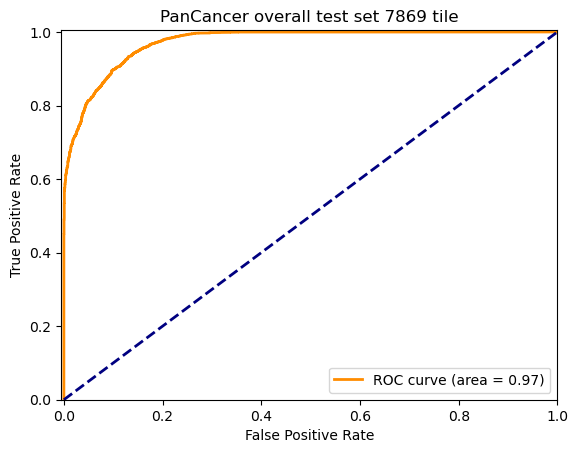

In [70]:
y_score = valid_df.p_pos.values
y_true = valid_df.loc[:,'anno']=='Tumor'
fpr, tpr, thr = skm.roc_curve(y_true,
                              y_score,
                              drop_intermediate=False)
print(len(fpr),len(tpr))
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([-0.005, 1.0])
plt.ylim([0, 1.005])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("PanCancer overall test set %d tile" % len(y_true))
plt.legend(loc="lower right")
plt.show()


In [74]:
def max_best_spec(t,sp,a):
    a = np.array(a)
    sp = np.array(sp)
    t0=t[np.argwhere(sp==np.max(sp))[0]]
    ti=np.argwhere(sp==np.max(sp))
    a0 = a[ti[0]]
    an = a0
    i=0
    while (an >= a0) and ((i+1) < len(ti)):
        i = i +1
        an = a[ti[i]]
        
    return t[ti[i-1]]

Best spec [0.9]


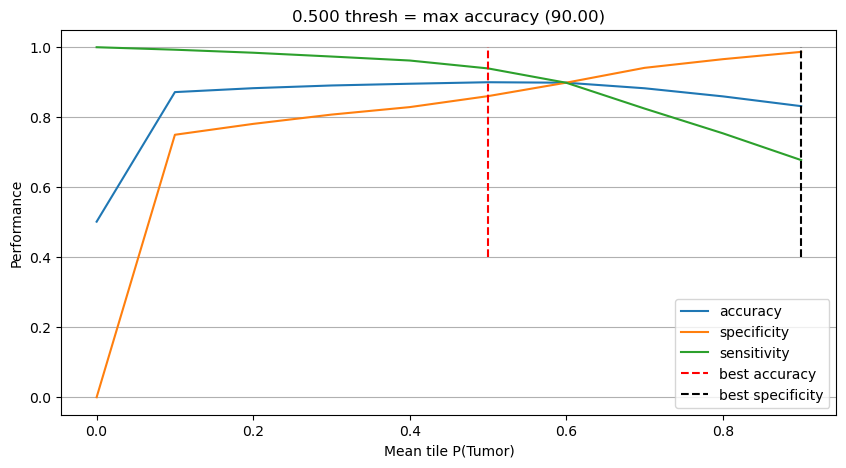

In [78]:
a = []
sp = []
sn = []
t = np.arange(0.0,1,0.1)
y_true = valid_df.loc[:,'anno'].values == 'Tumor'
for i in t:
    y_pred = valid_df.p_pos.values > i
    c = np.sum(y_true == y_pred)
    cm = skm.confusion_matrix(y_true, y_pred)
    accuracy = c/len(y_true)
    a.append(accuracy)
    specificity = cm[0,0] / np.sum(cm,axis=1)[0]
    sp.append(specificity)
    sensitivity = cm[1,1] /  np.sum(cm,axis=1)[1]
    sn.append(sensitivity)
    
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1)
ax.plot(t,a,label='accuracy')
best_t = t[np.argwhere(a==np.max(a))[0]]
ax.set_title('%1.3f thresh = max accuracy (%2.2f)' % (best_t, np.max(a)*100))

ax.plot(t,sp,label='specificity')
ax.plot(t,sn,label='sensitivity')
# plt.xticks(np.arange(0.075,0.3,0.01),rotation=90)
ax.plot([best_t,best_t],[0.4,1],'--r',label='best accuracy')

best_spec = max_best_spec(t,sp,a)
ax.plot([best_spec,best_spec],[0.4,1],'--k',label='best specificity')
ax.set_ylabel('Performance')
ax.set_xlabel('Mean tile P(Tumor)')
ax.legend()
plt.grid(axis='y')
print('Best spec',best_spec)

# Confusion matrix

Thresh 0.5 
Accuracy 0.8999872919049434 
Specificity 0.8602753697093319 
Sensitivity 0.9394476817836331
Thresh 0.7 
Accuracy 0.882704282628034 
Specificity 0.9411014788373279 
Sensitivity 0.8246769698505194


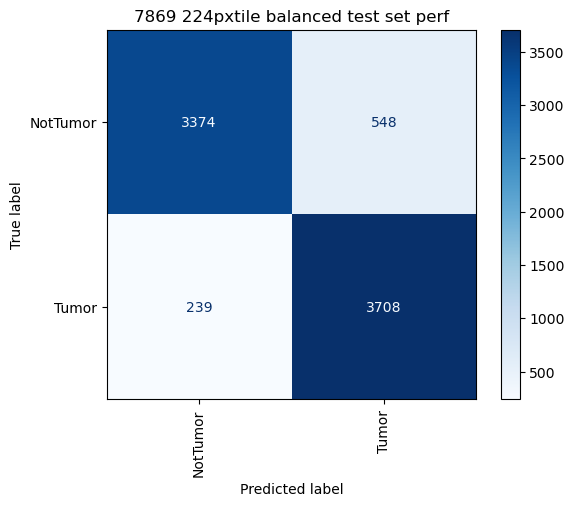

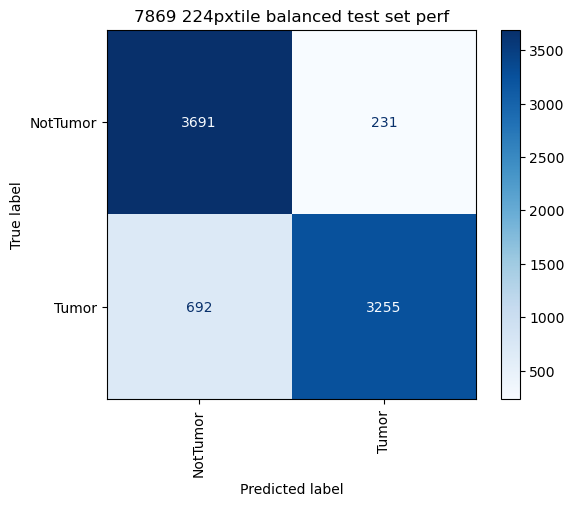

In [83]:
norm = False
# use_t = best_t
use_t = 0.5
threshes = [use_t,0.7] #0.7 looks like good trade-off for specificity
for use_t in threshes:
    y_true =  valid_df.loc[:,'anno'].values == 'Tumor'
    y_pred = valid_df.p_pos.values > use_t
    cm = skm.confusion_matrix(y_true, y_pred)
    if norm:
        cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
    disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['NotTumor','Tumor'])
    ax=disp.plot(cmap='Blues')
    plt.xticks(rotation=90)
    plt.title('%d 224pxtile balanced test set perf' % len(y_true))


    ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
    sp = cm[0,0] / np.sum(cm,axis=1)[0]
    sen = cm[1,1] /  np.sum(cm,axis=1)[1]
    print('Thresh',use_t,
          '\nAccuracy',ac, 
          '\nSpecificity',sp,
          '\nSensitivity',sen)

## Errors by cancer type

<AxesSubplot:xlabel='tissue', ylabel='err'>

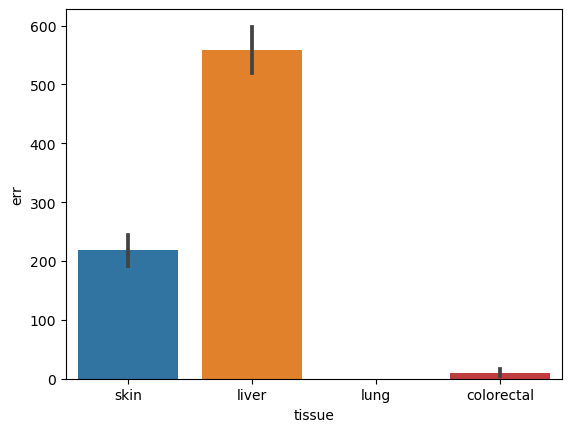

In [96]:
err = ((valid_df.pred_cls.values==1) & (valid_df.anno.values=='Tumor')) | \
      ((valid_df.pred_cls.values==0) & (valid_df.anno.values=='notTumor'))
valid_df.loc[:,'err'] = err
sns.barplot(valid_df,x='tissue',y='err',estimator='sum')
             

## Correct by cancer type

<AxesSubplot:xlabel='tissue', ylabel='fn'>

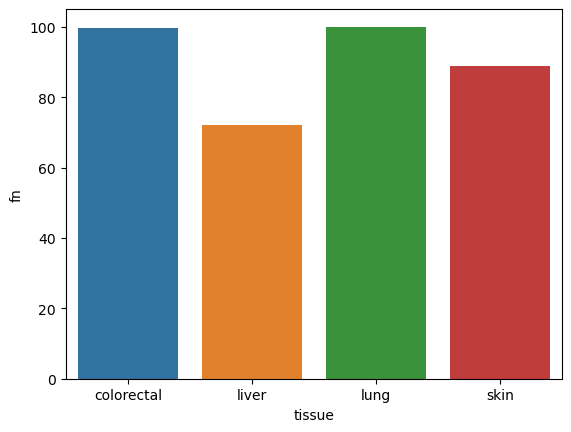

In [109]:
val= valid_df.loc[valid_df.cor==True,:].groupby(['tissue'])['fn'].count() / valid_df.groupby('tissue')['fn'].count() * 100
sns.barplot(val.reset_index(),x='tissue',y='fn')

#  Run inference on validation set of same cancer types

In [59]:
all_valid_df = all_df.loc[all_df.train.values == False,:].reset_index(drop=True)
all_valid_df.loc[:,'tissue_anno'] = all_valid_df.tissue + all_valid_df.anno
print(all_valid_df.groupby(['tissue_anno','train'])['fn'].count())
n_each = 1000
ds_valid = balance_df(all_valid_df, 
                      n_tumor_per_tissue = n_each,
                      state=36)
ds_valid = ds_valid.reset_index(drop=True)
ds_valid.groupby(['tissue_anno','train'])['fn'].count()

tissue_anno         train
colorectalTumor     False      4317
colorectalnotTumor  False     75683
liverTumor          False    147869
livernotTumor       False    851783
lungnotTumor        False       697
skinTumor           False      8309
skinnotTumor        False    342584
Name: fn, dtype: int64
skin 1000
liver 1000
lung 1000
colorectal 1000


tissue_anno         train
colorectalTumor     False    1000
colorectalnotTumor  False    1000
liverTumor          False    1000
livernotTumor       False    1000
lungnotTumor        False    1000
skinTumor           False    1000
skinnotTumor        False    1000
Name: fn, dtype: int64

In [ ]:
dl = learn.dls.test_dl(ds_valid.loc[:,'fn'] )
print('Beginning inference:')
pred = learn.get_preds(dl=dl, with_decoded=True) #Run with GPU to get time improvement?
p = np.array(pred[0])  # Probability ['neg','pos'] (Can check with dls.vocab )
c = np.array(pred[2])  # Predictions decoded
ds_valid.loc[:,'p_pos'] = p[:, 0] #['Tumor','notTumor']
ds_valid.loc[:,'pred_cls'] = c

## Save test inference results

In [100]:
cor = ((ds_valid.pred_cls.values==0) & (ds_valid.anno.values=='Tumor')) | \
      ((ds_valid.pred_cls.values==1) & (ds_valid.anno.values=='notTumor'))
ds_valid.loc[:,'cor'] = cor
err = ((ds_valid.pred_cls.values==1) & (ds_valid.anno.values=='Tumor')) | \
      ((ds_valid.pred_cls.values==0) & (ds_valid.anno.values=='notTumor'))
ds_valid.loc[:,'err'] = err

fn = infer_path.joinpath('%s_%d_dsvalid_pred.tsv' % (use_model, ds_valid.shape[0]))
print(fn)
ds_valid.to_csv(fn,sep='\t')

/ix/rbao/Projects/panCancer_HE/results/models/densenet169_bs375_n79984/infer_csv/densenet169_bs375_n79984_7000_dsvalid_pred.tsv


## Plot ROC curve

In [87]:
ds_valid.groupby(['anno','pred_cls'])['fn'].count()

anno      pred_cls
Tumor     0           2725
          1            275
notTumor  0            501
          1           3499
Name: fn, dtype: int64

In [101]:
cor = np.sum(ds_valid.cor)
acc = cor/ds_valid.shape[0] * 100
print(acc)

88.91428571428571


5325 5325


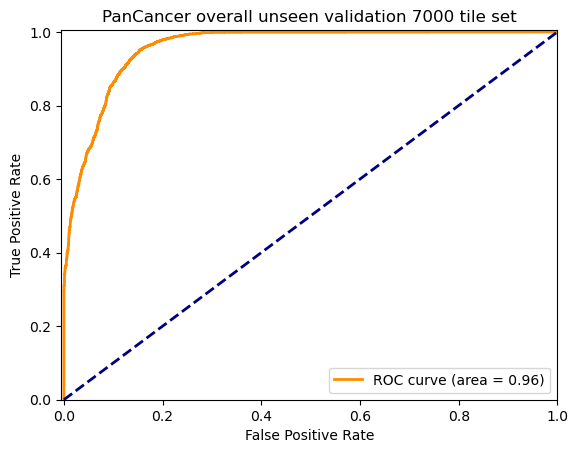

In [63]:
y_score = ds_valid.p_pos.values
y_true = ds_valid.loc[:,'anno']=='Tumor'
fpr, tpr, thr = skm.roc_curve(y_true,
                              y_score,
                              drop_intermediate=False)
print(len(fpr),len(tpr))
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([-0.005, 1.0])
plt.ylim([0, 1.005])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("PanCancer overall unseen validation %d tile set" % len(y_score))
plt.legend(loc="lower right")
plt.show()


<AxesSubplot:xlabel='tissue', ylabel='err'>

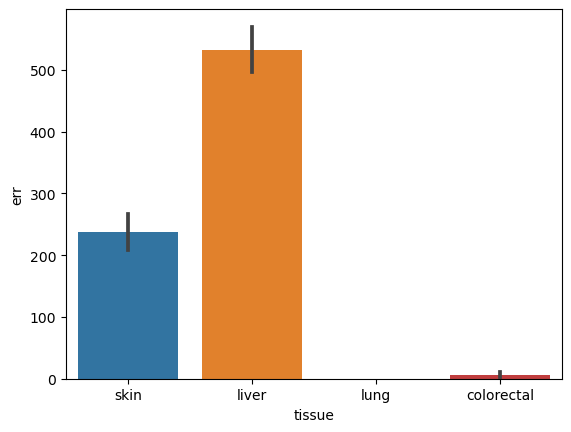

In [97]:

sns.barplot(ds_valid,x='tissue',y='err',estimator='sum')

## Accuracy by cancer type

<AxesSubplot:xlabel='tissue', ylabel='fn'>

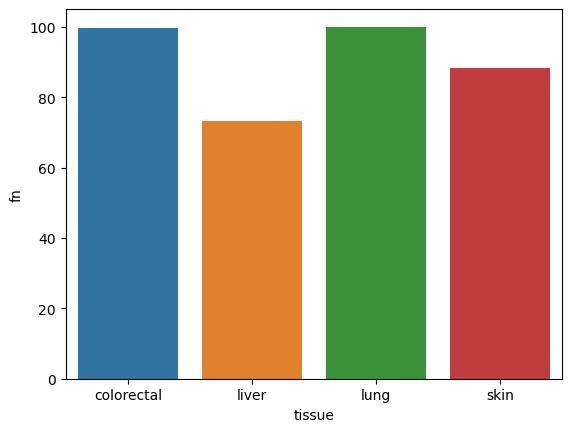

In [107]:
val= ds_valid.loc[ds_valid.cor==True,:].groupby(['tissue'])['fn'].count() / ds_valid.groupby('tissue')['fn'].count() * 100
sns.barplot(val.reset_index(),x='tissue',y='fn')

In [98]:
ds_valid.groupby('tissue')['fn'].count()
                           

tissue
colorectal    2000
liver         2000
lung          1000
skin          2000
Name: fn, dtype: int64

## Confusion matrix

Thresh 0.5 
Accuracy 0.8891428571428571 
Specificity 0.87475 
Sensitivity 0.9083333333333333
Thresh 0.9 
Accuracy 0.7588571428571429 
Specificity 0.9895 
Sensitivity 0.4513333333333333


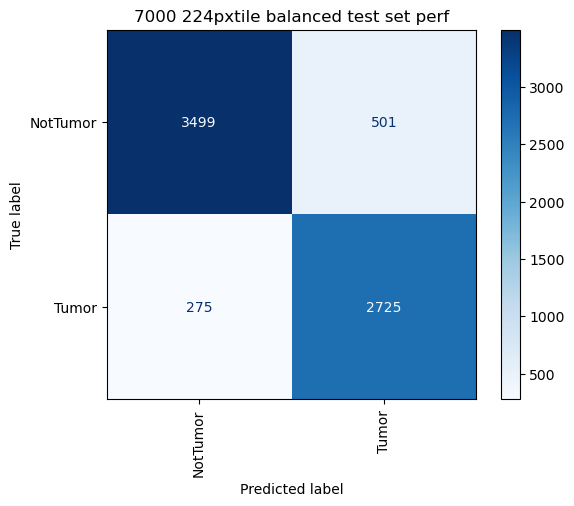

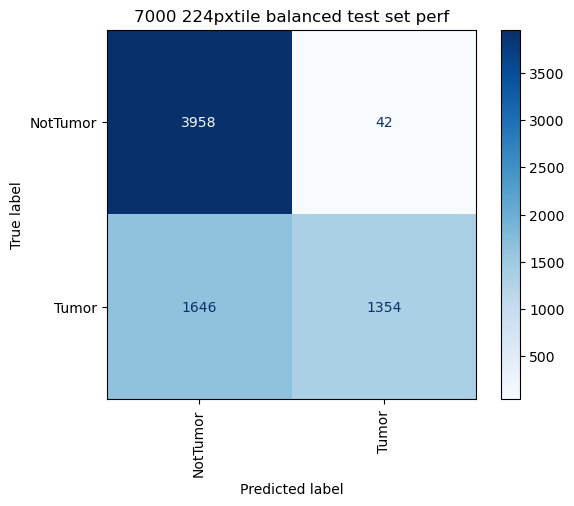

In [82]:
norm = False
# use_t = best_t
use_t = 0.5
threshes = [use_t,0.7]
for use_t in threshes:
    y_true =  ds_valid.loc[:,'anno'].values == 'Tumor'
    y_pred = ds_valid.p_pos.values > use_t
    cm = skm.confusion_matrix(y_true, y_pred)
    if norm:
        cm =  cm/ (np.ones((2,2)) * np.sum(cm,axis=1)).T
    disp = skm.ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['NotTumor','Tumor'])
    ax=disp.plot(cmap='Blues')
    plt.xticks(rotation=90)
    plt.title('%d 224pxtile balanced test set perf' % len(y_true))


    ac = (cm[0,0] + cm[1,1]) / np.sum(cm.reshape(-1,1))
    sp = cm[0,0] / np.sum(cm,axis=1)[0]
    sen = cm[1,1] /  np.sum(cm,axis=1)[1]
    print('Thresh',use_t,
          '\nAccuracy',ac, 
          '\nSpecificity',sp,
          '\nSensitivity',sen)

tile_df = pd.read_csv(sampleinfo.joinpath('tile_df_v8.0_298007_v4.tsv'),
                      dtype='str',
                      sep='\t')# Run Inference on pancreatic data

# Inference on pancreatic cancer samples

In [120]:
pdac_path= Path('/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/results/v8/models/densenet169_10fold_1rep_250bal_224px/csv/')
tile_path= '/ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/results/v8/tiles/224px/'
tile_df = pd.read_csv(pdac_path.joinpath('train_valid_fold_0.csv'))
tile_df.loc[:,'fn2'] = tile_path + tile_df.fn.str.split('_').str[0] + '/' + tile_df.fn 
tile_df.loc[:,'anno'] = 'notTumor'
tile_df.loc[tile_df.loc[:,'class'].values == 'malignant','anno'] = 'Tumor'
tile_df.groupby('anno')['fn2'].count()

anno
Tumor       3673
notTumor    3673
Name: fn2, dtype: int64

In [121]:
dl = learn.dls.test_dl(tile_df.loc[:,'fn2'] )
print('Beginning inference:')
pred = learn.get_preds(dl=dl, with_decoded=True) #Run with GPU to get time improvement?
p = np.array(pred[0])  # Probability ['neg','pos'] (Can check with dls.vocab )
c = np.array(pred[2])  # Predictions decoded
tile_df.loc[:,'p_pos'] = p[:, 0] # ['Tumor', 'notTumor'] (via dls.vocab)
tile_df.loc[:,'pred_cls'] = c

Beginning inference:


## Save

In [122]:
cor = ((tile_df.pred_cls.values==0) & (tile_df.anno.values=='Tumor')) | \
      ((tile_df.pred_cls.values==1) & (tile_df.anno.values=='notTumor'))
tile_df.loc[:,'cor'] = cor
err = ((tile_df.pred_cls.values==1) & (tile_df.anno.values=='Tumor')) | \
      ((tile_df.pred_cls.values==0) & (tile_df.anno.values=='notTumor'))
tile_df.loc[:,'err'] = err
fn = infer_path.joinpath('%s_%d_pdac_valid_pred.tsv' % (use_model, tile_df.shape[0]))
print(fn)
tile_df.to_csv(fn,sep='\t')

/ix/rbao/Projects/panCancer_HE/results/models/densenet169_bs375_n79984/infer_csv/densenet169_bs375_n79984_7346_pdac_valid_pred.tsv


6357 6357


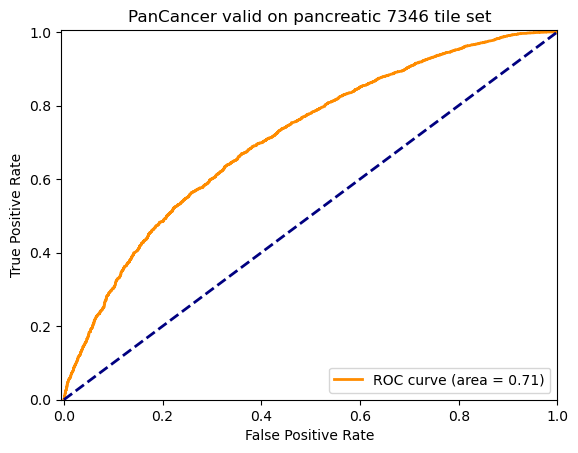

In [123]:
y_score = tile_df.p_pos.values
y_true = tile_df.loc[:,'anno']=='Tumor'
fpr, tpr, thr = skm.roc_curve(y_true,
                              y_score,
                              drop_intermediate=False)
print(len(fpr),len(tpr))
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([-0.005, 1.0])
plt.ylim([0, 1.005])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("PanCancer valid on pancreatic %d tile set" % len(y_score))
plt.legend(loc="lower right")
plt.show()


<AxesSubplot:xlabel='tissue', ylabel='fn'>

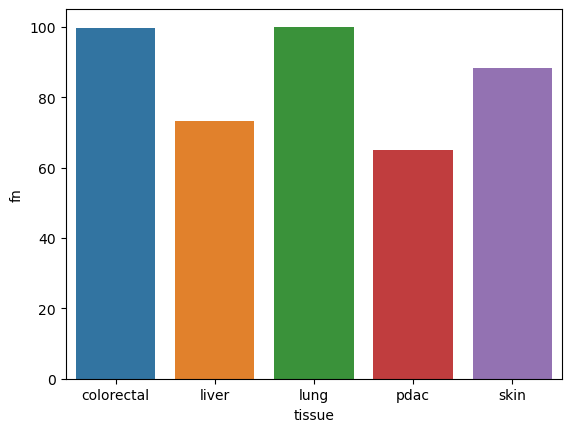

In [126]:
tile_df.loc[:,'tissue'] = 'pdac'
new = pd.concat((ds_valid.loc[:,['tissue','cor','fn','p_pos','anno']],
                 tile_df.loc[:,['tissue','cor','fn','p_pos','anno']]),axis=0)
val= new.loc[new.cor==True,:].groupby(['tissue'])['fn'].count() / new.groupby('tissue')['fn'].count() * 100
sns.barplot(val.reset_index(),x='tissue',y='fn')

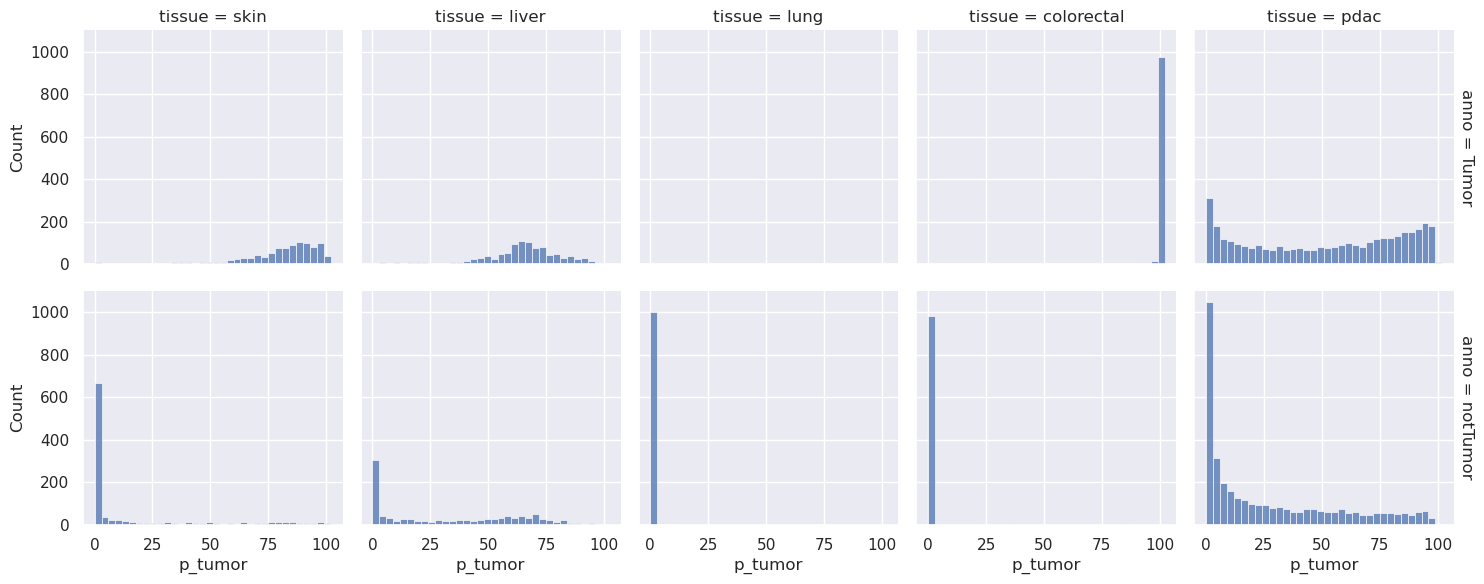

In [136]:
sns.set_theme(style="darkgrid")
new.loc[:,'p_tumor']=new.p_pos*100
sns.displot(
    new, x="p_tumor", col="tissue", row="anno",
    binwidth=3, height=3, facet_kws=dict(margin_titles=True),
)